# Session 5 — Non-Parametric Test Statistics

**Course: Event Studies in Finance & Economics**

*Mathis Mourey*

---

The parametric tests of Session 4 rely on two distributional assumptions: that abnormal returns are normally distributed and that the cross-sectional distribution is symmetric. In practice, daily stock returns are skewed and heavy-tailed (Fama, 1965), and the distribution of abnormal returns inherits these properties. When the sample is small, the central limit theorem provides only a weak approximation, and the parametric t-statistics can be misleading.

Non-parametric tests avoid the normality assumption by basing inference on the signs or ranks of the abnormal returns rather than on their magnitudes. This makes them robust to outliers, skewness, and heavy tails. The cost is typically a modest loss of power when the normality assumption happens to hold, but in exchange one obtains tests whose size is reliable under much weaker conditions.

This session develops three non-parametric tests that are standard in the event study literature: the simple sign test, the generalized sign test (Cowan, 1992), and the rank test (Corrado, 1989; Corrado and Zivney, 1992). We implement each test, apply it to the same earnings announcement dataset used in Sessions 2 through 4, and compare the results with the parametric tests. We close with a comprehensive comparison table and a discussion of which test to use when.

**References for this session:**

- Corrado, C.J. (1989). A Nonparametric Test for Abnormal Security-Price Performance in Event Studies. *Journal of Financial Economics*, 23(2), 385--395.
- Corrado, C.J. and Zivney, T.L. (1992). The Specification and Power of the Sign Test in Event Study Hypothesis Tests Using Daily Stock Returns. *Journal of Financial and Quantitative Analysis*, 27(3), 465--478.
- Cowan, A.R. (1992). Nonparametric Event Study Tests. *Review of Quantitative Finance and Accounting*, 2(4), 343--358.
- Fama, E.F. (1965). The Behavior of Stock-Market Prices. *Journal of Business*, 38(1), 34--105.
- Kolari, J.W. and Pynnonen, S. (2011). Nonparametric Rank Tests for Event Studies. *Journal of Empirical Finance*, 18(5), 953--971.
- MacKinlay, A.C. (1997). Event Studies in Economics and Finance. *Journal of Economic Literature*, 35(1), 13--39.
- Wilcoxon, F. (1945). Individual Comparisons by Ranking Methods. *Biometrics Bulletin*, 1(6), 80--83.

## 1. Why Non-Parametric Tests?

The parametric tests of Session 4 derive their distributions under the assumption that abnormal returns are normally distributed. When this assumption fails, the actual rejection rate under the null may differ from the nominal size. Brown and Warner (1985) showed that departures from normality are common in daily return data and that the Patell test, in particular, can over-reject when returns are skewed or leptokurtic.

Non-parametric tests replace the magnitude of the abnormal return with a simpler quantity: its sign (positive or negative) or its rank in the combined sample of estimation-window and event-window returns. Because these quantities depend only on the ordinal properties of the data, they are invariant to monotone transformations of returns and are unaffected by outliers.

The trade-off is straightforward. Under normality, the parametric t-test is the uniformly most powerful test for the mean (Neyman-Pearson lemma). Non-parametric tests sacrifice some power in this ideal case. But normality is the exception rather than the rule in financial data, and the power loss is small in most practical settings. Corrado (1989) and Cowan (1992) show through simulation that non-parametric tests often achieve power close to the parametric tests while maintaining correct size under a wider range of distributional assumptions.

## 2. Data and Setup

We reuse the same sample and estimation procedure as in Sessions 3 and 4. The code below reproduces the data pipeline and the market model estimation, yielding the panel of abnormal returns and the model parameters.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# -- Sample: same as Sessions 2-4 --
events = pd.DataFrame({
    'ticker': ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'JPM', 'JNJ', 'V', 'PG'],
    'event_date': pd.to_datetime([
        '2024-02-01', '2024-01-30', '2024-01-30', '2024-02-01',
        '2024-02-01', '2024-02-21', '2024-01-12', '2024-01-23',
        '2024-01-25', '2024-01-23'
    ]),
    'name': ['Apple', 'Microsoft', 'Alphabet', 'Amazon', 'Meta',
             'Nvidia', 'JPMorgan', 'Johnson & Johnson', 'Visa', 'Procter & Gamble']
})

market_ticker = '^GSPC'
start_date = '2022-06-01'
end_date = '2024-04-01'

data_market = yf.download(market_ticker, start=start_date, end=end_date, progress=False)
if isinstance(data_market.columns, pd.MultiIndex):
    data_market.columns = data_market.columns.get_level_values(0)
market_prices = data_market['Close']

all_tickers = events['ticker'].tolist()
data_firms = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
if isinstance(data_firms.columns, pd.MultiIndex):
    firm_prices = data_firms['Close']
else:
    firm_prices = data_firms[['Close']].rename(columns={'Close': all_tickers[0]})

market_returns = market_prices.pct_change().dropna()
firm_returns = firm_prices.pct_change().dropna()

common_idx = market_returns.index.intersection(firm_returns.index)
market_returns = market_returns.loc[common_idx]
firm_returns = firm_returns.loc[common_idx]

print(f"Sample: {len(events)} firms, {len(common_idx)} trading days")

YF.download() has changed argument auto_adjust default to True
Sample: 10 firms, 458 trading days


In [2]:
# -- Estimation and AR computation (same as Session 4) --
est_window_length = 250
buffer = 10
event_win = (-10, 10)
event_days = list(range(event_win[0], event_win[1] + 1))
trading_days = firm_returns.index

ar_panel = pd.DataFrame(index=event_days, columns=events['ticker'].values, dtype=float)
model_params = {}

# Also store full residual series for each firm (estimation + event window)
full_residuals = {}

for _, row in events.iterrows():
    tick = row['ticker']
    edate = row['event_date']

    event_idx = trading_days.get_indexer([edate], method='ffill')[0]
    event_start = event_idx + event_win[0]
    event_end = event_idx + event_win[1]
    est_end = event_start - buffer - 1
    est_start = est_end - est_window_length + 1

    if est_start < 0:
        print(f"  {tick}: insufficient data, skipping")
        continue

    y_est = firm_returns.iloc[est_start:est_end + 1][tick].values
    x_est = market_returns.iloc[est_start:est_end + 1].values
    valid = ~(np.isnan(y_est) | np.isnan(x_est))
    y_est_clean, x_est_clean = y_est[valid], x_est[valid]
    X_est = sm.add_constant(x_est_clean)
    ols = sm.OLS(y_est_clean, X_est).fit()
    alpha, beta = ols.params[0], ols.params[1]
    sigma = np.sqrt(ols.mse_resid)

    # Event-window ARs
    y_evt = firm_returns.iloc[event_start:event_end + 1][tick].values
    x_evt = market_returns.iloc[event_start:event_end + 1].values
    ar_evt = y_evt - (alpha + beta * x_evt)
    ar_panel[tick] = ar_evt

    # Full residuals: estimation window + buffer + event window
    y_full = firm_returns.iloc[est_start:event_end + 1][tick].values
    x_full = market_returns.iloc[est_start:event_end + 1].values
    ar_full = y_full - (alpha + beta * x_full)
    full_residuals[tick] = ar_full

    model_params[tick] = {
        'alpha': alpha, 'beta': beta, 'sigma': sigma,
        'L': len(y_est_clean),
        'est_start': est_start, 'est_end': est_end,
        'event_start': event_start, 'event_end': event_end,
    }

N = ar_panel.shape[1]
print(f"Processed {N} firms")
print(f"Full residual length per firm: ~{est_window_length + buffer + len(event_days)} days")

Processed 10 firms
Full residual length per firm: ~281 days


## 3. The Simple Sign Test

The sign test is the simplest non-parametric test for event studies. Under the null hypothesis of no event effect, the abnormal return on any event day is equally likely to be positive or negative. That is, $P(AR_{i,\tau} > 0) = 0.5$ under $H_0$. The sign test counts the number of positive CARs and compares it to the expected count under the null.

For a sample of $N$ firms with CARs computed over $[\tau_a, \tau_b]$, let $N^+$ denote the number of firms with $CAR_i > 0$. Under the null, $N^+$ follows a Binomial distribution with parameters $N$ and $p = 0.5$. The test statistic is:

$$
T_{sign} = \frac{N^+ - 0.5 N}{\sqrt{0.25 N}}
$$

which is asymptotically standard normal. For small $N$, one can use the exact binomial distribution instead.

The sign test has a well-known limitation: it assumes that the probability of a positive abnormal return under the null is exactly 0.5. This holds only if the distribution of abnormal returns is symmetric around zero. In practice, daily stock return distributions are slightly positively skewed, and the market model residuals may have a fraction of positive values that differs from 0.5. If the unconditional fraction of positive abnormal returns is, say, 0.52, the sign test will over-reject on the positive side and under-reject on the negative side. The generalized sign test (Section 4) corrects for this.

In [6]:
# -- Simple Sign Test --

def sign_test(ar_panel, windows):
    # Simple sign test: tests whether the fraction of positive CARs differs from 0.5.
    results = []
    N = ar_panel.shape[1]

    for tau_a, tau_b in windows:
        mask = (ar_panel.index >= tau_a) & (ar_panel.index <= tau_b)
        cars = ar_panel.loc[mask].sum(axis=0)
        n_pos = (cars > 0).sum()
        frac_pos = n_pos / N

        # Test statistic (normal approximation)
        t_stat = (n_pos - 0.5 * N) / np.sqrt(0.25 * N)
        p_val_norm = 2 * (1 - stats.norm.cdf(abs(t_stat)))

        # Exact binomial p-value (two-sided)
        p_val_exact = 2 * min(
            stats.binom.cdf(n_pos, N, 0.5),
            1 - stats.binom.cdf(n_pos - 1, N, 0.5)
        )
        p_val_exact = min(p_val_exact, 1.0)

        results.append({
            'Window': f'[{tau_a:+d}, {tau_b:+d}]',
            'N+': n_pos,
            'N-': N - n_pos,
            'Frac +': frac_pos,
            'z_sign': t_stat,
            'p (normal)': p_val_norm,
            'p (exact)': p_val_exact,
        })

    return pd.DataFrame(results)


windows = [(-10, 10), (-5, 5), (-1, 1), (0, 0), (0, 1), (1, 10)]
sign_results = sign_test(ar_panel, windows)
print("Simple Sign Test")
print("=" * 75)
print(sign_results.to_string(index=False, float_format='{:.4f}'.format))

Simple Sign Test
    Window  N+  N-  Frac +  z_sign  p (normal)  p (exact)
[-10, +10]   5   5  0.5000  0.0000      1.0000     1.0000
  [-5, +5]   5   5  0.5000  0.0000      1.0000     1.0000
  [-1, +1]   4   6  0.4000 -0.6325      0.5271     0.7539
  [+0, +0]   2   8  0.2000 -1.8974      0.0578     0.1094
  [+0, +1]   4   6  0.4000 -0.6325      0.5271     0.7539
 [+1, +10]   4   6  0.4000 -0.6325      0.5271     0.7539


## 4. The Generalized Sign Test (Cowan, 1992)

The generalized sign test replaces the assumed probability of 0.5 with the empirical fraction of positive abnormal returns in the estimation window. Let $\hat{p}_i$ denote the fraction of estimation-window days on which firm $i$'s abnormal return is positive:

$$
\hat{p}_i = \frac{1}{L_i} \sum_{t=1}^{L_i} \mathbf{1}\{AR_{i,t} > 0\}
$$

The average across firms is:

$$
\hat{p} = \frac{1}{N} \sum_{i=1}^{N} \hat{p}_i
$$

Under the null, $N^+$ follows a Binomial distribution with parameters $N$ and $\hat{p}$ (rather than 0.5). The test statistic is:

$$
T_{gsign} = \frac{N^+ - N\hat{p}}{\sqrt{N\hat{p}(1-\hat{p})}}
$$

This correction matters in practice. If $\hat{p} > 0.5$ (which is common because of the positive skewness of daily returns), the generalized sign test requires more positive CARs to reject than the simple sign test does. The result is a test with more accurate size control.

Cowan (1992) showed through simulation that the generalized sign test has correct size in settings where the simple sign test over-rejects, and that its power is only marginally lower.

In [9]:
# -- Generalized Sign Test (Cowan, 1992) --

def generalized_sign_test(ar_panel, model_params, events, trading_days, windows):
    # Generalized sign test using estimation-window fraction of positive ARs.
    N = ar_panel.shape[1]

    # Compute p_hat for each firm from estimation-window residuals
    p_hats = {}
    for tick in ar_panel.columns:
        p = model_params[tick]
        est_s, est_e = p['est_start'], p['est_end']
        y = firm_returns.iloc[est_s:est_e + 1][tick].values
        x = market_returns.iloc[est_s:est_e + 1].values
        resid = y - (p['alpha'] + p['beta'] * x)
        valid = ~np.isnan(resid)
        p_hats[tick] = np.mean(resid[valid] > 0)

    p_hat = np.mean(list(p_hats.values()))

    results = []
    for tau_a, tau_b in windows:
        mask = (ar_panel.index >= tau_a) & (ar_panel.index <= tau_b)
        cars = ar_panel.loc[mask].sum(axis=0)
        n_pos = (cars > 0).sum()
        frac_pos = n_pos / N

        t_stat = (n_pos - N * p_hat) / np.sqrt(N * p_hat * (1 - p_hat))
        p_val = 2 * (1 - stats.norm.cdf(abs(t_stat)))

        results.append({
            'Window': f'[{tau_a:+d}, {tau_b:+d}]',
            'N+': n_pos,
            'p_hat': p_hat,
            'Expected N+': N * p_hat,
            'z_gsign': t_stat,
            'p-value': p_val,
        })

    return pd.DataFrame(results), p_hat, p_hats


gsign_results, p_hat, p_hats = generalized_sign_test(
    ar_panel, model_params, events, trading_days, windows
)
print("Generalized Sign Test (Cowan, 1992)")
print("=" * 70)
print(f"Estimation-window fraction of positive ARs (p_hat): {p_hat:.4f}")
print(f"Firm-level p_hat range: [{min(p_hats.values()):.3f}, {max(p_hats.values()):.3f}]")
print()
print(gsign_results.to_string(index=False, float_format='{:.4f}'.format))

Generalized Sign Test (Cowan, 1992)
Estimation-window fraction of positive ARs (p_hat): 0.4884
Firm-level p_hat range: [0.432, 0.532]

    Window  N+  p_hat  Expected N+  z_gsign  p-value
[-10, +10]   5 0.4884       4.8840   0.0734   0.9415
  [-5, +5]   5 0.4884       4.8840   0.0734   0.9415
  [-1, +1]   4 0.4884       4.8840  -0.5592   0.5760
  [+0, +0]   2 0.4884       4.8840  -1.8245   0.0681
  [+0, +1]   4 0.4884       4.8840  -0.5592   0.5760
 [+1, +10]   4 0.4884       4.8840  -0.5592   0.5760


## 5. The Corrado Rank Test (1989)

The rank test proposed by Corrado (1989) is the most widely used non-parametric test in event studies. Rather than using the sign of the abnormal return, it uses its rank within the combined sample of estimation-window and event-window abnormal returns for each firm.

For firm $i$, let $K_{i,\tau}$ denote the rank of the event-day abnormal return $AR_{i,\tau}$ among all $T_i = L_i + T_w$ abnormal returns (estimation window plus event window). The ranks are standardized to have mean zero:

$$
U_{i,\tau} = \frac{K_{i,\tau}}{T_i + 1} - 0.5
$$

Under the null, the event-day abnormal return is exchangeable with any estimation-window abnormal return, so $U_{i,\tau}$ has mean zero and variance $1/12$ (the variance of a uniform random variable on $(-0.5, 0.5)$).

The rank test statistic for a single event day is:

$$
T_{rank}(\tau) = \frac{\frac{1}{N} \sum_{i=1}^{N} U_{i,\tau}}{\hat{S}_U}
$$

where $\hat{S}_U$ is the standard deviation of the daily average rank statistic, estimated from both the estimation window and the event window:

$$
\hat{S}_U = \sqrt{\frac{1}{T} \sum_{t=1}^{T} \left(\frac{1}{N} \sum_{i=1}^{N} U_{i,t}\right)^2}
$$

For a multi-day window $[\tau_a, \tau_b]$, the cumulative rank test statistic is:

$$
T_{rank}(\tau_a, \tau_b) = \frac{1}{\sqrt{T_w}} \sum_{\tau=\tau_a}^{\tau_b} T_{rank}(\tau)
$$

The rank test has several desirable properties. It is distribution-free under the null (no normality assumption is needed). It is robust to outliers (an extreme return affects only the rank, not the test statistic magnitude). And it has good power because it uses ordinal information rather than just the sign. Corrado and Zivney (1992) show that the rank test is well-specified across a wide range of return distributions and has power comparable to the parametric BMP test.

In [12]:
# -- Corrado Rank Test --

def corrado_rank_test(ar_panel, full_residuals, model_params, windows):
    # Corrado (1989) rank test using combined estimation + event window ranks.
    N = ar_panel.shape[1]
    tickers = ar_panel.columns.tolist()
    event_days_arr = ar_panel.index.values

    # Compute ranks for each firm
    # full_residuals[tick] contains estimation + buffer + event window residuals
    # We need the rank of each day within the full series
    rank_panel = pd.DataFrame(index=ar_panel.index, columns=tickers, dtype=float)

    for tick in tickers:
        resid_full = full_residuals[tick]
        T_total = len(resid_full)

        # Rank all residuals (1 to T_total)
        ranks = stats.rankdata(resid_full, method='average')

        # Standardize: U = rank / (T+1) - 0.5
        U = ranks / (T_total + 1) - 0.5

        # Extract event-window ranks (last len(event_days) entries)
        n_event = len(event_days_arr)
        U_event = U[-n_event:]
        rank_panel[tick] = U_event

    # Also compute U for the full period (for variance estimation)
    # Build full U panel (all days, all firms)
    max_len = max(len(full_residuals[t]) for t in tickers)
    full_U_means = []
    for day_offset in range(max_len):
        day_vals = []
        for tick in tickers:
            resid = full_residuals[tick]
            T_total = len(resid)
            if day_offset < T_total:
                ranks = stats.rankdata(resid, method='average')
                U = ranks / (T_total + 1) - 0.5
                day_vals.append(U[day_offset])
        if len(day_vals) == N:
            full_U_means.append(np.mean(day_vals))

    # Variance estimate from full period
    S_U = np.std(full_U_means, ddof=0)

    # Daily average rank statistic
    avg_U = rank_panel.mean(axis=1)

    results = []
    for tau_a, tau_b in windows:
        mask = (rank_panel.index >= tau_a) & (rank_panel.index <= tau_b)
        T_w = mask.sum()

        if T_w == 1:
            t_stat = avg_U.loc[mask].values[0] / S_U
        else:
            # Cumulative: sum of daily rank stats, scaled by sqrt(T_w)
            daily_stats = avg_U.loc[mask] / S_U
            t_stat = daily_stats.sum() / np.sqrt(T_w)

        p_val = 2 * (1 - stats.norm.cdf(abs(t_stat)))

        results.append({
            'Window': f'[{tau_a:+d}, {tau_b:+d}]',
            'Avg rank stat': avg_U.loc[mask].mean(),
            'S_U': S_U,
            'T_rank': t_stat,
            'p-value': p_val,
        })

    return pd.DataFrame(results), rank_panel, avg_U, S_U


rank_results, rank_panel, avg_U, S_U = corrado_rank_test(
    ar_panel, full_residuals, model_params, windows
)
print("Corrado Rank Test (1989)")
print("=" * 65)
print(rank_results.to_string(index=False, float_format='{:.4f}'.format))

Corrado Rank Test (1989)
    Window  Avg rank stat    S_U  T_rank  p-value
[-10, +10]        -0.0119 0.1017 -0.5343   0.5931
  [-5, +5]        -0.0537 0.1017 -1.7521   0.0798
  [-1, +1]        -0.0981 0.1017 -1.6714   0.0946
  [+0, +0]        -0.1475 0.1017 -1.4510   0.1468
  [+0, +1]        -0.1314 0.1017 -1.8276   0.0676
 [+1, +10]        -0.0151 0.1017 -0.4710   0.6377


## 6. Visualizing the Rank Structure

The rank panel contains information that is invisible in the raw abnormal returns. By plotting the average standardized rank across event time, we can see whether event-day returns are systematically higher (or lower) in the distribution than non-event-day returns, without being influenced by the magnitude of any single outlier.

A flat line near zero across all event days indicates no event effect. A spike at $\tau = 0$ indicates that event-day returns are systematically displaced from their usual position in the distribution.

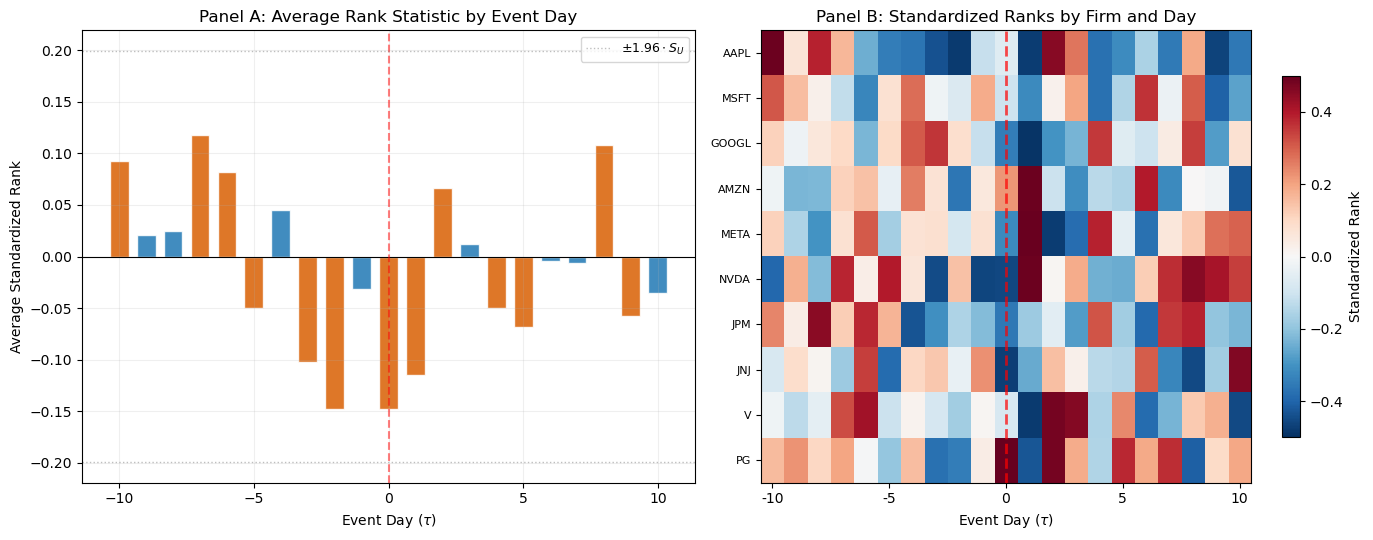

In [15]:
# -- Rank visualization --

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel A: Average standardized rank by event day
ax = axes[0]
colors = ['#d95f02' if abs(v) > 0.05 else '#1f78b4' for v in avg_U.values]
ax.bar(event_days, avg_U.values, color=colors, edgecolor='white', width=0.7, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.5)
ax.axhline(1.96 * S_U, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='$\pm 1.96 \cdot S_U$')
ax.axhline(-1.96 * S_U, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('Event Day ($\\tau$)')
ax.set_ylabel('Average Standardized Rank')
ax.set_title('Panel A: Average Rank Statistic by Event Day')
ax.legend(fontsize=9, frameon=True)
ax.grid(True, alpha=0.2)

# Panel B: Rank heatmap across firms and event days
ax = axes[1]
rank_vals = rank_panel.astype(float).values.T
im = ax.imshow(rank_vals, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5,
               interpolation='nearest')
ax.set_yticks(range(len(ar_panel.columns)))
ax.set_yticklabels(ar_panel.columns, fontsize=8)
tick_positions = [0, 5, 10, 15, 20]
ax.set_xticks(tick_positions)
ax.set_xticklabels([event_days[t] for t in tick_positions])
ax.axvline(10, color='red', linewidth=2, linestyle='--', alpha=0.7)
ax.set_xlabel('Event Day ($\\tau$)')
ax.set_title('Panel B: Standardized Ranks by Firm and Day')
plt.colorbar(im, ax=ax, label='Standardized Rank', shrink=0.8)

plt.tight_layout()
plt.show()

## 7. The Kolari-Pynnonen Generalized Rank Test (2011)

Kolari and Pynnonen (2011) proposed a generalized version of the Corrado rank test that addresses two limitations of the original. First, the original test uses ranks computed within each firm's combined estimation and event window, which means the ranks are not comparable across firms with different estimation window lengths or different return distributions. Second, the original test does not account for event-induced variance.

The generalized rank (GRANK) test standardizes the abnormal returns by their estimation-window standard deviation before ranking. This ensures that the ranks are comparable across firms. The test statistic is then constructed from the cross-sectional average of these standardized ranks, using the same variance estimator as the BMP test (cross-sectional variance in the event window).

The implementation proceeds in three steps. First, standardize each firm's abnormal returns by its estimation-window $\hat{\sigma}_{\varepsilon_i}$. Second, rank the standardized residuals within each firm's full sample. Third, compute the cross-sectional average rank and its standard error using the cross-sectional variance.

In [17]:
# -- Kolari-Pynnonen Generalized Rank Test (2011) --

def grank_test(ar_panel, full_residuals, model_params, windows):
    # GRANK test: standardize, then rank, then use cross-sectional variance.
    N = ar_panel.shape[1]
    tickers = ar_panel.columns.tolist()

    grank_panel = pd.DataFrame(index=ar_panel.index, columns=tickers, dtype=float)

    for tick in tickers:
        sigma_i = model_params[tick]['sigma']
        resid_full = full_residuals[tick]

        # Standardize by estimation-window sigma
        sar_full = resid_full / sigma_i

        # Rank the standardized residuals
        T_total = len(sar_full)
        ranks = stats.rankdata(sar_full, method='average')
        U = ranks / (T_total + 1) - 0.5

        # Extract event-window generalized ranks
        n_event = len(ar_panel.index)
        grank_panel[tick] = U[-n_event:]

    results = []
    for tau_a, tau_b in windows:
        mask = (grank_panel.index >= tau_a) & (grank_panel.index <= tau_b)
        window_gr = grank_panel.loc[mask]
        T_w = mask.sum()

        # Cumulative generalized rank for each firm
        cgr = window_gr.sum(axis=0) / np.sqrt(T_w)
        cgr_mean = cgr.mean()
        cgr_std = cgr.std(ddof=1)
        t_stat = cgr_mean / (cgr_std / np.sqrt(N))
        p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=N - 1))

        results.append({
            'Window': f'[{tau_a:+d}, {tau_b:+d}]',
            'Mean CGR': cgr_mean,
            'SD CGR': cgr_std,
            'T_GRANK': t_stat,
            'p-value': p_val,
        })

    return pd.DataFrame(results)


grank_results = grank_test(ar_panel, full_residuals, model_params, windows)
print("Kolari-Pynnonen Generalized Rank (GRANK) Test")
print("=" * 65)
print(grank_results.to_string(index=False, float_format='{:.4f}'.format))

Kolari-Pynnonen Generalized Rank (GRANK) Test
    Window  Mean CGR  SD CGR  T_GRANK  p-value
[-10, +10]   -0.0543  0.2327  -0.7381   0.4793
  [-5, +5]   -0.1781  0.2392  -2.3550   0.0430
  [-1, +1]   -0.1699  0.3026  -1.7759   0.1095
  [+0, +0]   -0.1475  0.3118  -1.4961   0.1688
  [+0, +1]   -0.1858  0.3444  -1.7058   0.1222
 [+1, +10]   -0.0479  0.3079  -0.4917   0.6347


## 8. Comprehensive Comparison: Parametric and Non-Parametric Tests

We now bring together all test statistics from Sessions 4 and 5. For the parametric tests, we recompute them here using the same code structure as Session 4 to ensure comparability. The goal is a single summary table that a researcher could include in a paper as a robustness check across multiple inferential approaches.

In [19]:
# -- Recompute parametric tests for the comparison table --

# Cross-sectional t-test
def cs_test_quick(ar_panel, tau_a, tau_b):
    N = ar_panel.shape[1]
    mask = (ar_panel.index >= tau_a) & (ar_panel.index <= tau_b)
    cars = ar_panel.loc[mask].sum(axis=0)
    caar = cars.mean()
    s = cars.std(ddof=1)
    t = caar / (s / np.sqrt(N))
    p = 2 * (1 - stats.t.cdf(abs(t), df=N - 1))
    return t, p

# Patell test (simplified)
def patell_quick(ar_panel, model_params, tau_a, tau_b):
    N = ar_panel.shape[1]
    mask = (ar_panel.index >= tau_a) & (ar_panel.index <= tau_b)
    T_w = mask.sum()
    sar = ar_panel.loc[mask].copy()
    for tick in sar.columns:
        sar[tick] = sar[tick] / model_params[tick]['sigma']
    csar = sar.sum(axis=0) / np.sqrt(T_w)
    t = np.sqrt(N) * csar.mean()
    p = 2 * (1 - stats.norm.cdf(abs(t)))
    return t, p

# BMP test
def bmp_quick(ar_panel, model_params, tau_a, tau_b):
    N = ar_panel.shape[1]
    mask = (ar_panel.index >= tau_a) & (ar_panel.index <= tau_b)
    T_w = mask.sum()
    sar = ar_panel.loc[mask].copy()
    for tick in sar.columns:
        sar[tick] = sar[tick] / model_params[tick]['sigma']
    csar = sar.sum(axis=0) / np.sqrt(T_w)
    t = csar.mean() / (csar.std(ddof=1) / np.sqrt(N))
    p = 2 * (1 - stats.t.cdf(abs(t), df=N - 1))
    return t, p

# Build comparison table
rows = []
for tau_a, tau_b in windows:
    mask = (ar_panel.index >= tau_a) & (ar_panel.index <= tau_b)
    caar = ar_panel.loc[mask].sum(axis=0).mean() * 100

    t_cs, p_cs = cs_test_quick(ar_panel, tau_a, tau_b)
    t_pa, p_pa = patell_quick(ar_panel, model_params, tau_a, tau_b)
    t_bmp, p_bmp = bmp_quick(ar_panel, model_params, tau_a, tau_b)

    # Non-parametric: extract from results DataFrames
    idx = windows.index((tau_a, tau_b))
    t_sign = sign_results.iloc[idx]['z_sign']
    p_sign = sign_results.iloc[idx]['p (exact)']
    t_gsign = gsign_results.iloc[idx]['z_gsign']
    p_gsign = gsign_results.iloc[idx]['p-value']
    t_rank = rank_results.iloc[idx]['T_rank']
    p_rank = rank_results.iloc[idx]['p-value']
    t_grank = grank_results.iloc[idx]['T_GRANK']
    p_grank = grank_results.iloc[idx]['p-value']

    rows.append({
        'Window': f'[{tau_a:+d}, {tau_b:+d}]',
        'CAAR (%)': caar,
        't_CS': t_cs, 'p_CS': p_cs,
        't_Patell': t_pa, 'p_Patell': p_pa,
        't_BMP': t_bmp, 'p_BMP': p_bmp,
        'z_Sign': t_sign, 'p_Sign': p_sign,
        'z_GSign': t_gsign, 'p_GSign': p_gsign,
        'T_Rank': t_rank, 'p_Rank': p_rank,
        'T_GRANK': t_grank, 'p_GRANK': p_grank,
    })

full_comparison = pd.DataFrame(rows)

print("Comprehensive Comparison: All Test Statistics")
print("=" * 100)

# Panel A: Test statistics
print("\nPanel A: Test Statistics")
cols_t = ['Window', 'CAAR (%)', 't_CS', 't_Patell', 't_BMP', 'z_Sign', 'z_GSign', 'T_Rank', 'T_GRANK']
print(full_comparison[cols_t].to_string(index=False, float_format='{:.3f}'.format))

# Panel B: p-values
print("\nPanel B: p-values (* < .10, ** < .05, *** < .01)")
cols_p = ['Window', 'p_CS', 'p_Patell', 'p_BMP', 'p_Sign', 'p_GSign', 'p_Rank', 'p_GRANK']
print(full_comparison[cols_p].to_string(index=False, float_format='{:.4f}'.format))

Comprehensive Comparison: All Test Statistics

Panel A: Test Statistics
    Window  CAAR (%)   t_CS  t_Patell  t_BMP  z_Sign  z_GSign  T_Rank  T_GRANK
[-10, +10]     1.721  0.793     0.342  0.327   0.000    0.073  -0.534   -0.738
  [-5, +5]     0.470  0.261    -0.234 -0.184   0.000    0.073  -1.752   -2.355
  [-1, +1]     1.672  0.795     0.876  0.391  -0.632   -0.559  -1.671   -1.776
  [+0, +0]    -0.443 -0.723    -0.275 -0.158  -1.897   -1.824  -1.451   -1.496
  [+0, +1]     1.982  0.912     1.302  0.469  -0.632   -0.559  -1.828   -1.706
 [+1, +10]     2.548  0.946     0.678  0.482  -0.632   -0.559  -0.471   -0.492

Panel B: p-values (* < .10, ** < .05, *** < .01)
    Window   p_CS  p_Patell  p_BMP  p_Sign  p_GSign  p_Rank  p_GRANK
[-10, +10] 0.4480    0.7321 0.7513  1.0000   0.9415  0.5931   0.4793
  [-5, +5] 0.7999    0.8146 0.8582  1.0000   0.9415  0.0798   0.0430
  [-1, +1] 0.4469    0.3812 0.7047  0.7539   0.5760  0.0946   0.1095
  [+0, +0] 0.4882    0.7830 0.8781  0.1094   0.06

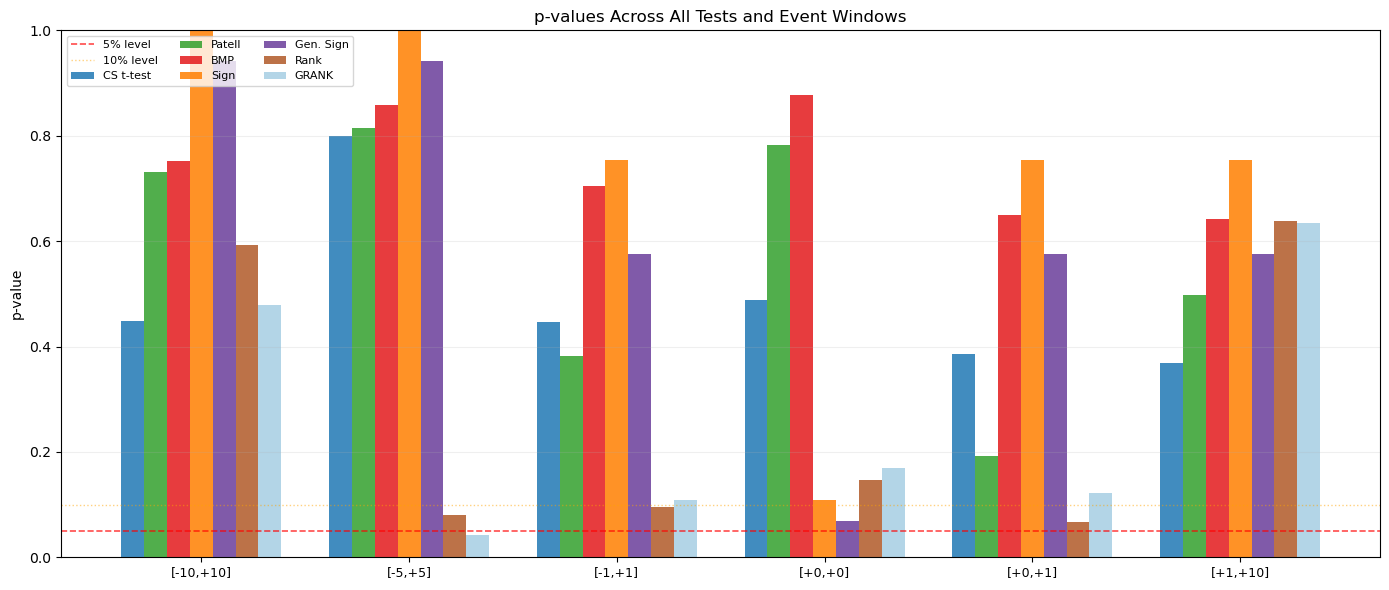

In [21]:
# -- Visual comparison of p-values across all tests --

fig, ax = plt.subplots(figsize=(14, 6))

tests = ['p_CS', 'p_Patell', 'p_BMP', 'p_Sign', 'p_GSign', 'p_Rank', 'p_GRANK']
test_labels = ['CS t-test', 'Patell', 'BMP', 'Sign', 'Gen. Sign', 'Rank', 'GRANK']
colors = ['#1f78b4', '#33a02c', '#e31a1c', '#ff7f00', '#6a3d9a', '#b15928', '#a6cee3']

x_pos = np.arange(len(windows))
width = 0.11

for j, (test, label, color) in enumerate(zip(tests, test_labels, colors)):
    offset = (j - 3) * width
    ax.bar(x_pos + offset, full_comparison[test], width, label=label, color=color, alpha=0.85)

ax.axhline(0.05, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='5% level')
ax.axhline(0.10, color='orange', linestyle=':', linewidth=1, alpha=0.5, label='10% level')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'[{a:+d},{b:+d}]' for a, b in windows], fontsize=9)
ax.set_ylabel('p-value')
ax.set_title('p-values Across All Tests and Event Windows')
ax.legend(fontsize=8, frameon=True, ncol=3, loc='upper left')
ax.set_ylim(0, min(1.0, full_comparison[tests].max().max() + 0.05))
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

## 9. Inspecting the Distribution of Abnormal Returns

The choice between parametric and non-parametric tests depends on the shape of the abnormal return distribution. If the distribution is approximately normal, the parametric tests are efficient and the non-parametric tests offer little advantage. If the distribution is skewed or heavy-tailed, the non-parametric tests provide better size control.

We examine the distributional properties of the event-window abnormal returns directly: a histogram, a Q-Q plot against the normal distribution, and formal tests of normality (Jarque-Bera and Shapiro-Wilk).

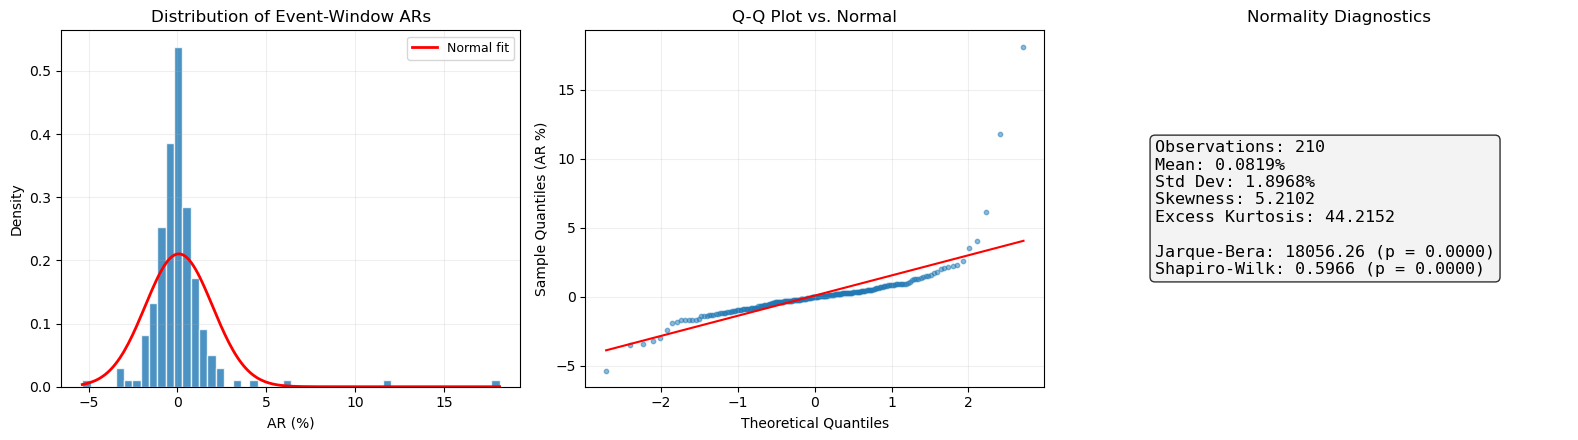

The Jarque-Bera test rejects normality at 5%. Non-parametric tests are warranted.


In [25]:
# -- Distributional analysis of event-window ARs --

# Pool all event-window ARs
all_ars = ar_panel.values.flatten()
all_ars = all_ars[~np.isnan(all_ars)]

skew = stats.skew(all_ars)
kurt = stats.kurtosis(all_ars)  # excess kurtosis
jb_stat, jb_p = stats.jarque_bera(all_ars)
sw_stat, sw_p = stats.shapiro(all_ars[:5000] if len(all_ars) > 5000 else all_ars)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Histogram
ax = axes[0]
ax.hist(all_ars * 100, bins=50, density=True, color='#1f78b4', edgecolor='white', alpha=0.8)
x_grid = np.linspace(all_ars.min() * 100, all_ars.max() * 100, 200)
ax.plot(x_grid, stats.norm.pdf(x_grid, loc=all_ars.mean() * 100, scale=all_ars.std() * 100),
        'r-', linewidth=2, label='Normal fit')
ax.set_xlabel('AR (%)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Event-Window ARs')
ax.legend(fontsize=9, frameon=True)
ax.grid(True, alpha=0.2)

# Q-Q plot
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(all_ars, dist='norm')
ax.scatter(osm, osr * 100, s=10, alpha=0.5, color='#1f78b4')
ax.plot(osm, (slope * osm + intercept) * 100, 'r-', linewidth=1.5)
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles (AR %)')
ax.set_title('Q-Q Plot vs. Normal')
ax.grid(True, alpha=0.2)

# Summary stats box
ax = axes[2]
ax.axis('off')
stats_text = (
    f"Observations: {len(all_ars)}\n"
    f"Mean: {all_ars.mean()*100:.4f}%\n"
    f"Std Dev: {all_ars.std()*100:.4f}%\n"
    f"Skewness: {skew:.4f}\n"
    f"Excess Kurtosis: {kurt:.4f}\n"
    f"\nJarque-Bera: {jb_stat:.2f} (p = {jb_p:.4f})\n"
    f"Shapiro-Wilk: {sw_stat:.4f} (p = {sw_p:.4f})"
)
ax.text(0.1, 0.5, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='center', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))
ax.set_title('Normality Diagnostics')

plt.tight_layout()
plt.show()

if jb_p < 0.05:
    print("The Jarque-Bera test rejects normality at 5%. Non-parametric tests are warranted.")
else:
    print("The Jarque-Bera test does not reject normality. Parametric tests are adequate.")

## 10. Practical Recommendations

The results from this session and Session 4 can be summarized in a set of guidelines for applied work.

**Baseline specification.** Report the BMP test (or Kolari-Pynnonen adjusted BMP when events cluster) as the primary parametric test, and the GRANK test (or the Corrado rank test) as the primary non-parametric test. This combination provides robustness to event-induced variance, cross-sectional correlation, non-normality, and outliers.

**When the tests disagree.** If parametric tests reject but non-parametric tests do not, the rejection is likely driven by a small number of outliers. Inspect the cross-sectional distribution of CARs (Panel D of the four-panel figure from Session 3). If non-parametric tests reject but parametric tests do not, the event effect may be present but masked by high variance in a few firms. The sign and rank tests, by ignoring magnitudes, can detect a consistent directional effect that the mean-based tests miss.

**Small samples.** With $N < 20$, use the exact binomial distribution for the sign and generalized sign tests rather than the normal approximation. The rank test remains valid for small $N$ because its null distribution is known exactly (it is a permutation distribution), though the asymptotic approximation may be inaccurate.

**Reporting.** A well-executed event study reports at least one parametric and one non-parametric test. Presenting the full comparison table (Section 8) in an appendix demonstrates thoroughness and allows readers to assess the sensitivity of the conclusions to the choice of test.

## 11. Summary and Preview of Session 6

This session developed four non-parametric tests for event study inference: the simple sign test, the generalized sign test (Cowan, 1992), the Corrado rank test (1989), and the Kolari-Pynnonen generalized rank (GRANK) test (2011).

The sign test is the simplest but assumes symmetric abnormal returns under the null, which rarely holds exactly. The generalized sign test corrects for asymmetry by calibrating the null fraction of positive returns from the estimation window. The Corrado rank test uses ordinal information (ranks rather than signs), achieving higher power while remaining distribution-free. The GRANK test combines standardization with ranking and uses the cross-sectional variance estimator, providing robustness to event-induced variance in addition to non-normality.

The comprehensive comparison in Section 8 showed the degree to which the seven test statistics (three parametric, four non-parametric) agree or disagree for our earnings announcement sample. When all tests point in the same direction, the conclusion is firm. When they diverge, the pattern of disagreement is informative about the data-generating process: outliers, event-induced variance, or calendar-time clustering.

Session 6 moves beyond the question "is the CAAR different from zero?" to the question "what explains the cross-sectional variation in CARs?" This is the domain of cross-sectional regression analysis: regressing firm-level CARs on firm characteristics (size, book-to-market, leverage, earnings surprise magnitude) to identify the determinants of the event effect.

**Additional references:**

- Campbell, J.Y., Lo, A.W. and MacKinlay, A.C. (1997). *The Econometrics of Financial Markets*. Princeton University Press, Chapter 4.
- Corrado, C.J. and Truong, C. (2008). Conducting Event Studies with Asia-Pacific Security Market Data. *Pacific-Basin Finance Journal*, 16(5), 493--521.
- Kolari, J.W. and Pynnonen, S. (2011). Nonparametric Rank Tests for Event Studies. *Journal of Empirical Finance*, 18(5), 953--971.
- Luoma, T. (2011). Nonparametric Event Study Tests for Testing Cumulative Abnormal Returns. Working Paper, Vaasa University.